# Harder synthetic-100 regression: standard model comparison

This notebook evaluates common regression alternatives on exactly the harder
synthetic dataset used by the MiSTIC kernel comparison: 500 samples, 100
features, target noise 60, redundant-proxy noise 30%, the same fixed 375/125
training/blind split, and ten seeded four-fold inner-CV searches.

Models include ridge, elastic net, partial least squares (PLS), random forest,
extra trees, histogram gradient boosting, and a mean dummy baseline. Blind data
are never used for tuning. Top-20 known-signal recovery is estimated afterward
using permutation importance computed on training data only.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.datasets import make_regression
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))

base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=60.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.30 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=0.25, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")


Training rows: 375; fixed blind rows: 125


In [3]:
def metrics(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def model_specs(seed):
    return {
        "Ridge": (
            Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
            {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        ),
        "Elastic net": (
            Pipeline([("scale", StandardScaler()),
                      ("model", ElasticNet(max_iter=20_000, random_state=seed))]),
            {"model__alpha": [0.001, 0.01, 0.1, 1.0],
             "model__l1_ratio": [0.1, 0.5, 0.9]},
        ),
        "PLS regression": (
            Pipeline([("scale", StandardScaler()),
                      ("model", PLSRegression(scale=False, max_iter=1_000))]),
            {"model__n_components": [2, 5, 10, 20]},
        ),
        "Random forest": (
            RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=1),
            {"max_depth": [None, 8], "max_features": [0.5, 1.0],
             "min_samples_leaf": [1, 3]},
        ),
        "Extra trees": (
            ExtraTreesRegressor(n_estimators=300, random_state=seed, n_jobs=1),
            {"max_depth": [None, 8], "max_features": [0.5, 1.0],
             "min_samples_leaf": [1, 3]},
        ),
        "Histogram gradient boosting": (
            HistGradientBoostingRegressor(max_iter=300, random_state=seed),
            {"learning_rate": [0.03, 0.1], "max_leaf_nodes": [15, 31],
             "l2_regularization": [0.1, 1.0]},
        ),
    }


def signal_recovery(estimator, seed):
    importance = permutation_importance(
        estimator, X_train, y_train, scoring="r2", n_repeats=3,
        random_state=seed, n_jobs=-1,
    ).importances_mean
    top20 = np.argsort(-importance, kind="stable")[:20]
    signal_count = len(set(top20).intersection(SIGNAL_FEATURES))
    return signal_count / 20, top20


## Execute the paired benchmark

Each hyperparameter search optimizes four-fold CV R². The seed changes inner
folds and stochastic estimator construction but never the blind observations.


In [4]:
rows = []
for seed in INNER_SEEDS:
    cv = KFold(n_splits=4, shuffle=True, random_state=seed)
    for method, (estimator, grid) in model_specs(seed).items():
        search = GridSearchCV(
            estimator, grid, scoring="r2", cv=cv, n_jobs=-1, refit=True,
        ).fit(X_train, y_train)
        predictions = np.asarray(search.predict(X_blind)).ravel()
        recall, top20 = signal_recovery(search.best_estimator_, seed)
        rows.append({
            "seed": seed, "method": method,
            "cv_best_score": search.best_score_,
            "top20_signal_recall": recall,
            "best_params": str(search.best_params_),
            **metrics(y_blind, predictions),
        })
        print(f"seed={seed}, completed {method}")

    dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
    rows.append({
        "seed": seed, "method": "Mean dummy", "cv_best_score": np.nan,
        "top20_signal_recall": np.nan, "best_params": "{}",
        **metrics(y_blind, dummy.predict(X_blind)),
    })

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_harder_standard_models_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


seed=0, completed Ridge


seed=0, completed Elastic net


seed=0, completed PLS regression


seed=0, completed Random forest


seed=0, completed Extra trees


...

seed=9, completed Random forest


seed=9, completed Extra trees


seed=9, completed Histogram gradient boosting


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_86699/2890679511.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(y_true, predictions).statistic


,seed,method,cv_best_score,top20_signal_recall,best_params,r2,rmse,mae,pearson_r2
0,0,Ridge,0.820392,0.70,{'model__alpha': 10.0},0.756413,0.421811,0.336764,0.764053
1,0,Elastic net,0.848430,0.55,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9}",0.791372,0.390371,0.319385,0.794832
2,0,PLS regression,0.805464,0.80,{'model__n_components': 5},0.744243,0.432219,0.344530,0.753678
3,0,Random forest,0.487520,0.65,"{'max_depth': None, 'max_features': 1.0, 'min_...",0.561137,0.566182,0.465825,0.587123
4,0,Extra trees,0.551454,0.70,"{'max_depth': None, 'max_features': 1.0, 'min_...",0.579338,0.554316,0.456285,0.623728
...,...,...,...,...,...,...,...,...,...
65,9,PLS regression,0.817546,0.75,{'model__n_components': 20},0.748926,0.428244,0.340733,0.766556
66,9,Random forest,0.517269,0.70,"{'max_depth': 8, 'max_features': 1.0, 'min_sam...",0.561974,0.565641,0.461825,0.592591
67,9,Extra trees,0.564148,0.70,"{'max_depth': None, 'max_features': 1.0, 'min_...",0.576723,0.556036,0.456243,0.622000
68,9,Histogram gradient boosting,0.685138,0.65,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.618612,0.527806,0.417126,0.619322


In [5]:
summary = results.groupby("method")[[
    "r2", "rmse", "mae", "pearson_r2", "cv_best_score", "top20_signal_recall"
]].agg(["mean", "std"])
summary.round(4)


r2            rmse             mae          \
                               mean     std    mean     std    mean     std   
method                                                                        
Elastic net                  0.7914  0.0000  0.3904  0.0000  0.3194  0.0000   
Extra trees                  0.5741  0.0049  0.5577  0.0032  0.4579  0.0028   
Histogram gradient boosting  0.6203  0.0022  0.5267  0.0015  0.4142  0.0038   
Mean dummy                  -0.0092  0.0000  0.8586  0.0000  0.6994  0.0000   
PLS regression               0.7471  0.0031  0.4298  0.0026  0.3421  0.0022   
Random forest                0.5575  0.0091  0.5685  0.0059  0.4659  0.0061   
Ridge                        0.7564  0.0000  0.4218  0.0000  0.3368  0.0000   

                            pearson_r2         cv_best_score          \
                                  mean     std          mean     std   
method                                                                 
Elastic net                     0.7948  0.0000        0.8417  0.0057   
Extra trees                     0.6195  0.0051        0.5453  0.0155   
Histogram gradient boosting     0.6213  0.0027        0.6597  0.0145   
Mean dummy                         NaN     NaN           NaN     NaN   
PLS regression                  0.7630  0.0058        0.8026  0.0092   
Random forest                   0.5989  0.0117        0.4944  0.0184   
Ridge                           0.7641  0.0000        0.8098  0.0098   

                            top20_signal_recall          
                                           mean     std  
method                                                   
Elastic net                               0.550  0.0000  
Extra trees                               0.725  0.0264  
Histogram gradient boosting               0.660  0.0211  
Mean dummy                                  NaN     NaN  
PLS regression                            0.780  0.0350  
Random forest                             0.705  0.0643  
Ridge                                     0.735  0.0337

In [6]:
mistic_results = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_harder_kernel_comparison_10seeds_results.csv"
)
selected_mistic = mistic_results[mistic_results["method"].isin([
    "MiSTIC linear, weight=0.75 (20 members)",
    "sklearn linear: knee-ranked unified",
    "sklearn SVR: linear-SVR RFE (20)",
    "sklearn SVR: all 100 features",
])][["seed", "method", "r2", "rmse", "mae", "pearson_r2", "top20_signal_recall"]]
comparison = pd.concat([
    results[["seed", "method", "r2", "rmse", "mae", "pearson_r2", "top20_signal_recall"]],
    selected_mistic,
], ignore_index=True)

best_method = comparison.groupby("method")["r2"].mean().idxmax()
best = comparison.query("method == @best_method").set_index("seed")
paired_rows = []
for method, frame in comparison.groupby("method"):
    if method == best_method:
        continue
    delta = best["r2"] - frame.set_index("seed")["r2"]
    paired_rows.append({
        "best_method": best_method, "compared_with": method,
        "mean_r2_advantage": delta.mean(), "std_difference": delta.std(ddof=1),
        "best_wins": int((delta > 0).sum()), "ties": int((delta == 0).sum()),
        "best_losses": int((delta < 0).sum()),
    })
paired = pd.DataFrame(paired_rows).sort_values("mean_r2_advantage")
print(best_method)
paired.round(4)


sklearn linear: knee-ranked unified


,best_method,compared_with,mean_r2_advantage,std_difference,best_wins,ties,best_losses
0,sklearn linear: knee-ranked unified,Elastic net,0.0170,0.0064,10,0,0
9,sklearn linear: knee-ranked unified,sklearn SVR: linear-SVR RFE (20),0.0212,0.0067,10,0,0
4,sklearn linear: knee-ranked unified,"MiSTIC linear, weight=0.75 (20 members)",0.0254,0.0103,10,0,0
7,sklearn linear: knee-ranked unified,Ridge,0.0520,0.0064,10,0,0
5,sklearn linear: knee-ranked unified,PLS regression,0.0613,0.0069,10,0,0
8,sklearn linear: knee-ranked unified,sklearn SVR: all 100 features,0.0734,0.0064,10,0,0
2,sklearn linear: knee-ranked unified,Histogram gradient boosting,0.1881,0.0060,10,0,0
1,sklearn linear: knee-ranked unified,Extra trees,0.2343,0.0086,10,0,0
6,sklearn linear: knee-ranked unified,Random forest,0.2509,0.0082,10,0,0
3,sklearn linear: knee-ranked unified,Mean dummy,0.8177,0.0064,10,0,0


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_86699/1908464705.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=comparison, y="method", x="r2", order=order,


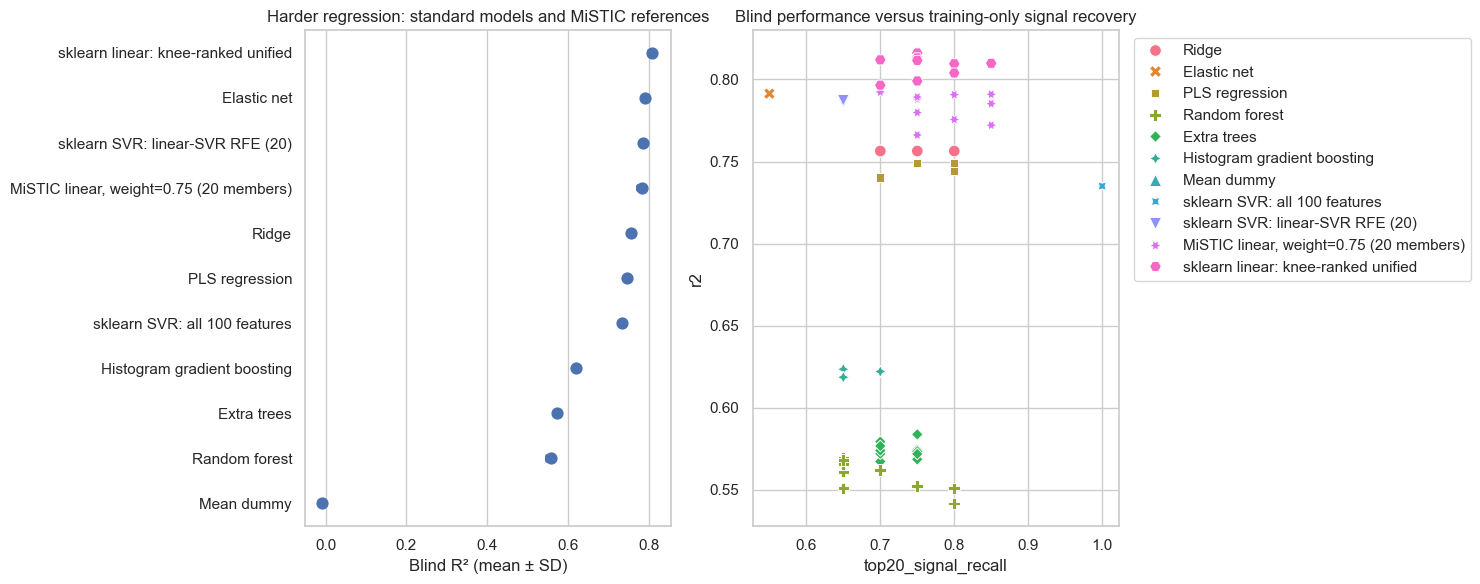

In [7]:
order = comparison.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.pointplot(data=comparison, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.10, ax=axes[0])
axes[0].set_title("Harder regression: standard models and MiSTIC references")
axes[0].set_xlabel("Blind R² (mean ± SD)")
axes[0].set_ylabel("")
sns.scatterplot(data=comparison, x="top20_signal_recall", y="r2",
                hue="method", style="method", s=70, ax=axes[1])
axes[1].set_title("Blind performance versus training-only signal recovery")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_harder_standard_models_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

All seeds share one blind set. Permutation importance is computed on training
data only and is used for descriptive signal-recovery analysis, not model
selection. Repeated seeded fits quantify modeling sensitivity rather than
uncertainty over independently sampled test sets.
